 # Email Phishing Detection Model with BERT for Tokenization

For more information regarding the model and other important information, check the README file.

**AVN Phishing Email Classification Dataset**\
From AVN Bluefox (Amritha V Nair) - 2025. Under CC BY 4.0 License\
https://www.kaggle.com/datasets/avnbluefox/avn-phishing-email-classification-dataset?select=AVN_Corpus.csv

## Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from email.utils import parseaddr

import tensorflow as tf
import keras
from IPython.core.pylabtools import figsize

I0000 00:00:1785410906.686443  220533 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785410906.686755  220533 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785410906.715695  220533 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785410909.709684  220533 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
df = pd.read_csv('data/AVN_Corpus.csv')
df

,subject,receiver,sender,label,body,urls,date
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,"Tue, 05 Aug 2008 16:31:02 -0700"
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,"Tue, 05 Aug 2008 18:31:03 -0500"
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,"Tue, 05 Aug 2008 20:28:00 -1200"
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,"Tue, 05 Aug 2008 17:31:20 -0600"
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,"Tue, 05 Aug 2008 19:31:21 -0400"
...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,NaN,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,NaN
59432,TREAT AS URGENT.,NaN,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,"Mon, 17 Sep 2007 22:28:11 +0000"
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,NaN,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,"Tue, 18 Sep 2007 10:54:53 +0000"
59434,My Beloved In Christ.,NaN,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,"Wed, 19 Sep 2007 00:52:16 +0100"


We first check to see the distribution of null values to see how we should perform data cleaning.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59436 entries, 0 to 59435
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   48209 non-null  str    
 1   receiver  46296 non-null  str    
 2   sender    47961 non-null  str    
 3   label     59436 non-null  float64
 4   body      59436 non-null  str    
 5   urls      59436 non-null  int64  
 6   date      47810 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 3.2 MB


We first perform checks on the `label` variable to identify any potential class imbalance within the dataset.

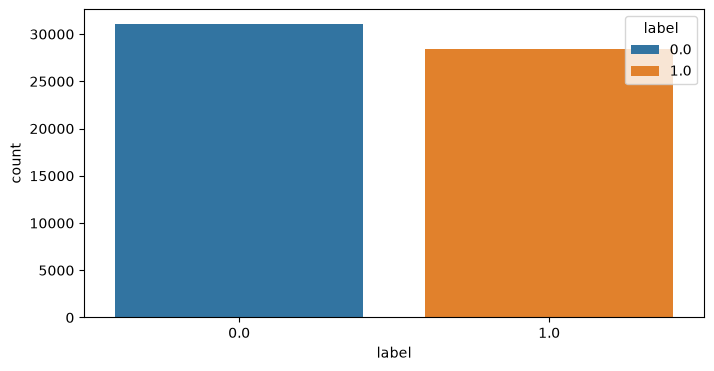

label
0.0    31053
1.0    28383
Name: count, dtype: int64

In [4]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='label', hue='label')
plt.show()

df['label'].value_counts()

From the `label` data above, the class distribution is roughly **even**, with a distribution of:
- 31,053 (52.2%) of emails being normal
- 28,383 (47.8%) of emails being malicious

The null values with `subject`, `sender`, `receiver` and `date` fields make up ~20% of the total number of fields within the dataset.

Hence, we fill the null values for `subject`, `sender` and `receiver` with **"Unknown"** fields as these null values can have potentially reveal special relationships within the data.

For the `date` field, an indicator `is_date_valid` to check whether it has a defined (and valid) date and then parse the value within `date` (see below).

In [5]:
df["subject"] = df["subject"].fillna("No Subject")
df["sender"] = df["sender"].fillna("Unknown Sender")
df["receiver"] = df["receiver"].fillna("Unknown Receiver")

df["is_date_invalid"] = df["date"].isna().astype(np.float32) # 1 if invalid, 0 if valid

df.sample(5)

,subject,receiver,sender,label,body,urls,date,is_date_invalid
12813,Re: [exmh-users] replying to text/plain base64,Discussion list for EXMH users <ndqq-lmbvh@red...,Kevin Cosgrove <mwrlcg@doink.com>,0.0,"\nOn 13 October 2007 at 8:34, Neil W Rickert ...",1,"Wed, 06 Aug 2008 06:39:00 -0700",0.0
3208,"Ted, Only 24 Hours Left to Order for Valentine...",user6@gvc.ceas-challenge.cc,Secret Spoon <laswrxryaso@offers.secretspoon.com>,0.0,\nCan't view Secret Spoon Sweets' weekly e-mai...,1,"Tue, 05 Aug 2008 20:41:43 -0600",0.0
43599,No Subject,Unknown Receiver,Unknown Sender,0.0,COME BACK TO TAMPA FFFFUUUUUUU,0,NaN,1.0
49252,No Subject,Unknown Receiver,Unknown Sender,0.0,Cos i was out shopping wif darren jus now n i ...,0,NaN,1.0
10278,Re: [opensuse] openSUSE 11.0 and the Non-ready...,wkilxloc@opensuse.org,"""Rajko M."" <jugxoi340@charter.net>",0.0,On Thursday 14 February 2008 11:55:24 pm Steph...,1,"Wed, 06 Aug 2008 03:31:01 -0600",0.0


The `date` column **is adjusted for UTC**, and then parsed into 4 unique fields which are:
- `hour`
- `day_of_week`: day of the week (Mon (0) - Sun (6))
- `month`
- `year`

The original `date` column will be dropped.

In [6]:
df['date'] = pd.to_datetime(df['date'], errors="coerce", utc=True)

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df = df.drop('date', axis=1)

df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week,month,year
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,8.0,2008.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,8.0,2008.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,8.0,2008.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,8.0,2008.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,8.0,2008.0
...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,9.0,2007.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,9.0,2007.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,9.0,2007.0


With the extracted subfields, we perform EDA to explore patterns with how these features interact with the target variable.

We first analyze the distribution of emails based on the time of day (`hour`), to answer whether:
- Are phishing emails more common within certain times of the day, such as working hours?
- Do most legitimate emails occur within the same time range as most phishing emails?

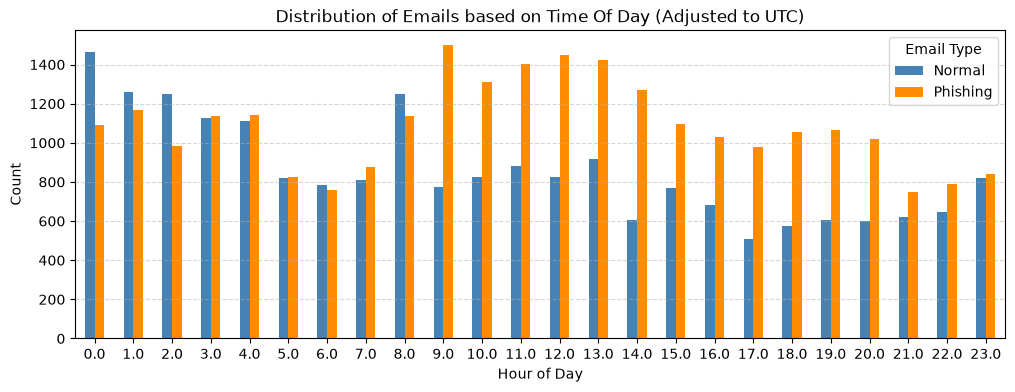

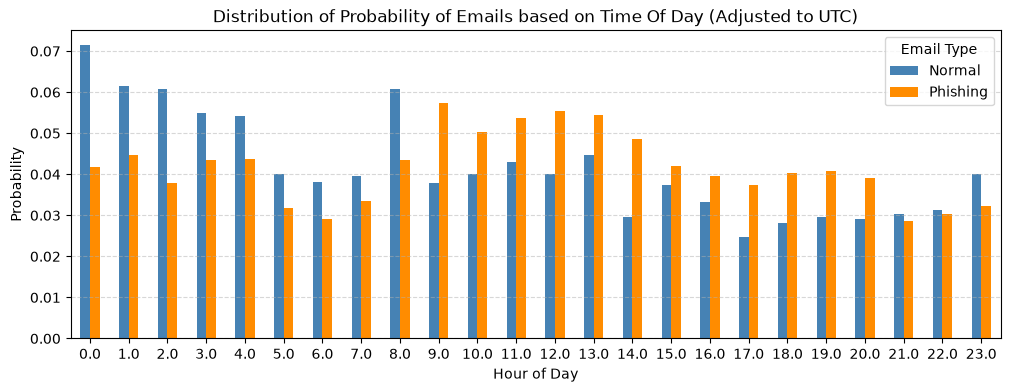

In [7]:
# pure count
counts = pd.crosstab(df['hour'], df['label'])
ax = counts.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])

plt.title("Distribution of Emails based on Time Of Day (Adjusted to UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['hour'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(12, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])

plt.title("Distribution of Probability of Emails based on Time Of Day (Adjusted to UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Based on the distribution of data, we find that:
- Most phishing emails are present throughout **09:00 to 20:00 UTC**, with most legitimate ones being distributed mostly between **23:00 to 04:00** and **08:00 UTC**
- There is a **clear difference** between the distribution of normal and phishing emails

Hence, we keep the `hour` feature as we believe that this feature contains useful predictive power.

After parsing `hour`, we then analyze the day of the week (`day_of_week`) to answer:
- Are phishing emails more common within weekdays as supposed to weekends?
- What is the overall distribution of emails within the week?

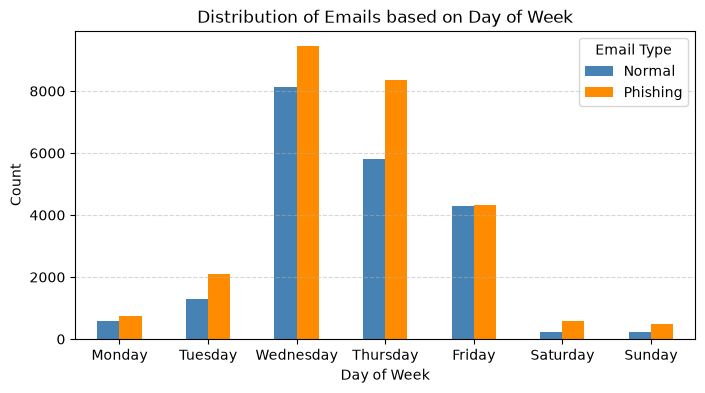

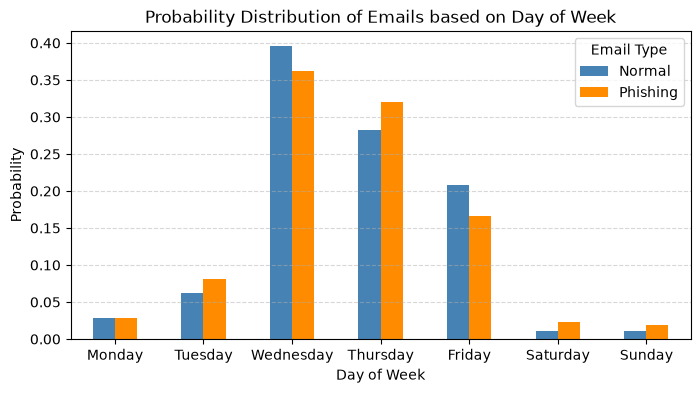

In [8]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# pure count
counts = pd.crosstab(df['day_of_week'], df['label'])
ax = counts.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(weekdays)), xticklabels=weekdays)

plt.title("Distribution of Emails based on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['day_of_week'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(weekdays)), xticklabels=weekdays)

plt.title("Probability Distribution of Emails based on Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

From the data, we observe:
- **Majority** of all emails fall within **Wednesday to Friday**, with the **weekends tending to have significant lower emails**
- Normal emails and phishing emails follow the **same trend** throughout the week

Therefore, we keep the `day_of_week` feature as we believe that feature is useful in predicting the trends of emails throughout the week.

After parsing `month`, we then analyze the month of the year (`month`) to answer:
- Are there any trends in phishing emails based on the months of the year?
- What is the overall distribution of emails within the year, do summer / winter holiday periods reduce the number?

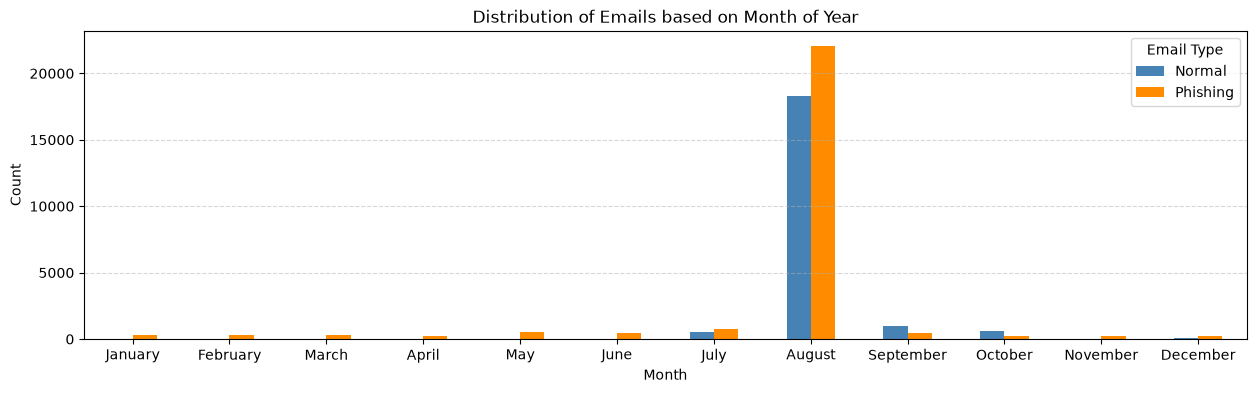

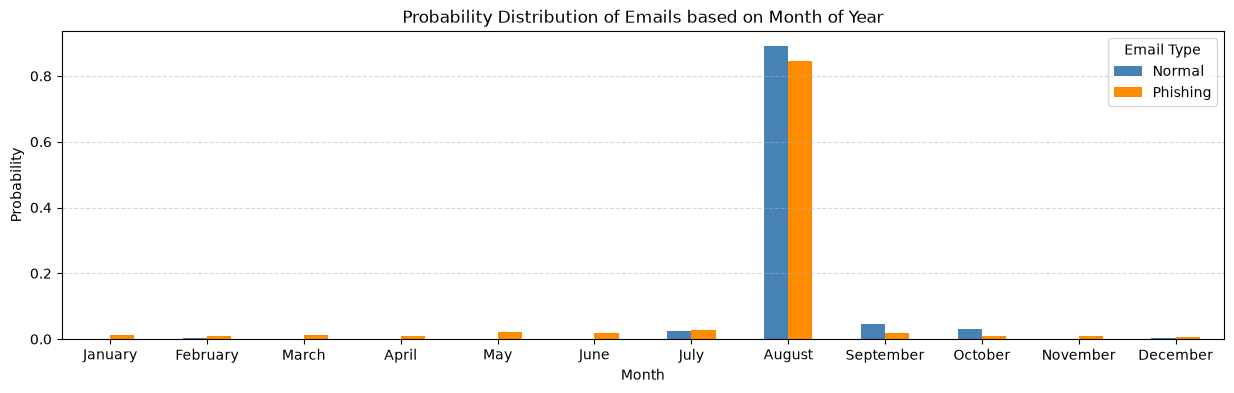

In [9]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

# pure count
counts = pd.crosstab(df['month'], df['label'])
ax = counts.plot(kind='bar', figsize=(15, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(months)), xticklabels=months)

plt.title("Distribution of Emails based on Month of Year")
plt.xlabel("Month")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# percentage (%) of each label
counts = pd.crosstab(df['month'], df['label'], normalize='columns')
ax = counts.plot(kind='bar', figsize=(15, 4), color=['steelblue', 'darkorange'])

ax.legend(title="Email Type", labels=["Normal", "Phishing"])
ax.set(xticks=range(len(months)), xticklabels=months)

plt.title("Probability Distribution of Emails based on Month of Year")
plt.xlabel("Month")
plt.ylabel("Probability")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

From the data, we observe:
- **Practically all emails are sent from August**, other months have a *negligible* percentage of emails
- Both normal and phishing emails follow this trend

Thus, we decide to drop `month`, since we believe that this distribution is because of how the data within the dataset was obtained.

In [10]:
df = df.drop('month', axis=1)
df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week,year
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0,2008.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0,2008.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0,2008.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0,2008.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0,2008.0
...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0,2007.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0,2007.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0,2007.0


The `year` column, just like `month`, contains a heavily imbalanced set, with **2008 making up more than 65% of emails**.

Hence, we also drop `year` since it doesn't contain any useful predictive value.

In [11]:
df['year'].value_counts()

year
2008.0    38947
2002.0     4548
2006.0     1006
2005.0      553
2007.0      466
2004.0      424
2003.0      396
2001.0      109
102.0        59
2000.0       35
2009.0       15
1980.0       12
1998.0        7
1999.0        6
2100.0        4
2020.0        4
1986.0        2
1990.0        2
2086.0        1
2012.0        1
2080.0        1
2031.0        1
1981.0        1
2010.0        1
2028.0        1
1997.0        1
2082.0        1
2015.0        1
Name: count, dtype: int64

In [12]:
df = df.drop('year', axis=1)
df

,subject,receiver,sender,label,body,urls,is_date_invalid,hour,day_of_week
0,Never agree to be a loser,user4@gvc.ceas-challenge.cc,Young Esposito <Young@iworld.de>,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,23.0,1.0
1,Befriend Jenna Jameson,user2.2@gvc.ceas-challenge.cc,Mok <ipline's1983@icable.ph>,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,23.0,1.0
2,CNN.com Daily Top 10,user2.9@gvc.ceas-challenge.cc,Daily Top 10 <Karmandeep-opengevl@universalnet...,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,8.0,2.0
3,Re: svn commit: r619753 - in /spamassassin/tru...,SpamAssassin Dev <xrh@spamassassin.apache.org>,Michael Parker <ivqrnai@pobox.com>,0.0,Would anyone object to removing .so from this ...,1,0.0,23.0,1.0
4,SpecialPricesPharmMoreinfo,user2.2@gvc.ceas-challenge.cc,Gretchen Suggs <externalsep1@loanofficertool.com>,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,23.0,1.0
...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,Unknown Receiver,michealagu0255@zipmail.com.br,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN
59432,TREAT AS URGENT.,Unknown Receiver,ali sherif <ali_sherif252@hotmail.fr>,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,22.0,0.0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,Unknown Receiver,Dr Usman Ibrahim Danko <drusmanibrahimtg08@hot...,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,10.0,1.0
59434,My Beloved In Christ.,Unknown Receiver,Mother Doris Killam <motherdorisk61@hotmail.com>,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,23.0,1.0


## Data Cleaning & Preprocessing

After completing EDA, we now prepare the dataset for the model.

The `hour` and `day_of_week` are **periodic features** (i.e. they happen in cycles and repeat),
hence encoding this features with a raw number may result in models seeing a big jump between values that are actually adjacent,
such as between **11:00 PM (23)** and **12:00AM (0)** for `hour`.

Therefore, in order to ensure that the model capture the cyclic nature of these features, we use **cyclic encoding** (sin / cos) to encode these fields.

**Both the sine and cosine** is used to create unique values for each value of `hour` and `day_of_week`,
since just using one function results in duplicates sharing the same value.

The original `hour` and `day_of_week` fields are dropped.

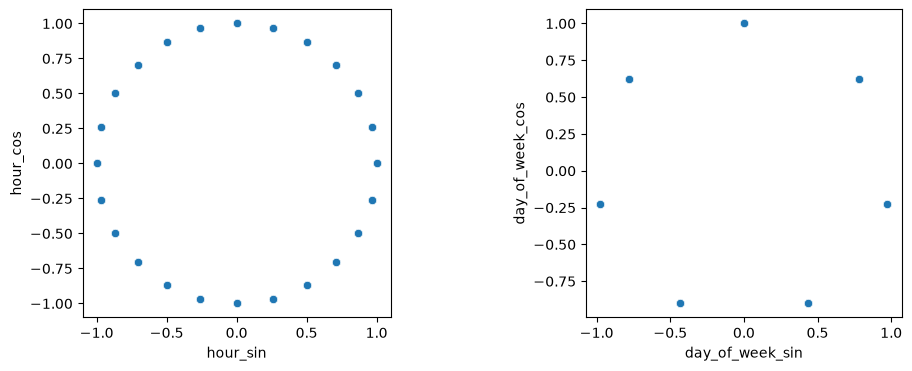

In [13]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7.0)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7.0)

df = df.drop(['hour', 'day_of_week'], axis=1)

# we encode the features with both sin and cos to allow the model to capture the relationship below
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(df, x='hour_sin', y='hour_cos', ax=ax[0]).set_aspect('equal')
sns.scatterplot(df, x='day_of_week_sin', y='day_of_week_cos', ax=ax[1]).set_aspect('equal')

For `sender` and `receiver`, it would likely better to extract the features given that the domain of the email and other information is more useful.

We use the `parseaddr()` function provided by Python's `email` stdlib import, which handles most of the raw email parsing. After parsing, we split the contents of the email into different components,
like name, username, domain, TLD, before feature engineering.

In [14]:
def parse_sender_receiver(raw):
    name, email = parseaddr(raw)
    name = name.strip().replace('\\"', '"').strip('"').strip()
    email = email.lower().strip()
    return name, email

def extract_email_components(email):
    if '@' not in email:
        return "", "", ""
    username, domain = email.split('@', 1)
    tld = domain.split(".")[-1] if "." in domain else ""
    return username, domain, tld

df[["sender_name", "sender_email"]] = df['sender'].apply(parse_sender_receiver).apply(pd.Series)
df[["receiver_name", "receiver_email"]] = df["receiver"].apply(parse_sender_receiver).apply(pd.Series)

df[["sender_username", "sender_domain", "sender_tld"]] = df["sender_email"].apply(extract_email_components).apply(pd.Series)
df[["receiver_username", "receiver_domain", "receiver_tld"]] = df["receiver_email"].apply(extract_email_components).apply(pd.Series)

df["is_sender_name_missing"] = (df["sender_name"] == "").astype(int)
df["is_sender_email_missing"] = (df["sender_email"].str.contains("@", na=False) == False).astype(int)

df["sender_email_has_digits"] = df["sender_email"].str.contains(r"\d").astype(int)
df["sender_email_has_hyphens"] = df["sender_email"].str.contains("-").astype(int)

df['sender_username_length'] = df['sender_username'].str.len()
df['receiver_username_length'] = df['receiver_username'].str.len()

df['sender_domain_length'] = df['sender_domain'].str.len()
df['receiver_domain_length'] = df['receiver_domain'].str.len()

# drop the sender and receiver column, as well as the other temporary features
df = df.drop(['sender', 'sender_name', 'sender_email', 'sender_username', 'sender_domain', 'sender_tld'], axis=1)
df = df.drop(['receiver', 'receiver_name', 'receiver_email', 'receiver_username', 'receiver_domain', 'receiver_tld'], axis=1)

df

,subject,label,body,urls,is_date_invalid,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,is_sender_name_missing,is_sender_email_missing,sender_email_has_digits,sender_email_has_hyphens,sender_username_length,receiver_username_length,sender_domain_length,receiver_domain_length
0,Never agree to be a loser,1.0,"Buck up, your troubles caused by small dimensi...",1,0.0,-0.258819,0.965926,0.781831,0.623490,0,0,0,0,5,5,9,21
1,Befriend Jenna Jameson,1.0,\nUpgrade your sex and pleasures with these te...,1,0.0,-0.258819,0.965926,0.781831,0.623490,0,0,1,0,12,7,9,21
2,CNN.com Daily Top 10,1.0,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,0.0,0.866025,-0.500000,0.974928,-0.222521,0,0,0,1,19,7,19,21
3,Re: svn commit: r619753 - in /spamassassin/tru...,0.0,Would anyone object to removing .so from this ...,1,0.0,-0.258819,0.965926,0.781831,0.623490,0,0,0,0,7,3,9,23
4,SpecialPricesPharmMoreinfo,1.0,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,0.0,-0.258819,0.965926,0.781831,0.623490,0,0,1,0,12,7,19,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59431,CONTACT GLOBAL MAX SHIPING COMPANY,1.0,"Atten: My Dear ,\n \nI have Paid the fee for y...",0,1.0,NaN,NaN,NaN,NaN,1,0,1,0,14,0,14,0
59432,TREAT AS URGENT.,1.0,\nFrom: Mr Ali Sherif. African Development Ban...,1,0.0,-0.500000,0.866025,0.000000,1.000000,0,0,1,0,13,0,10,0
59433,From Dr Usman Ibrahim / Mr Wahid Yoffe property.,1.0,\nFROM DR USMAN IBRAHIM DANKO.AUDITING AND ACC...,1,0.0,0.500000,-0.866025,0.781831,0.623490,0,0,1,0,18,0,10,0
59434,My Beloved In Christ.,1.0,"\nBeloved in the Lord Jesus Christ, PLEASE END...",1,0.0,-0.258819,0.965926,0.781831,0.623490,0,0,1,0,14,0,11,0
